In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
RANDOM_STATE   = 42


In [3]:
FEATURES       = ["Price", "Overall Rating", "Number Sold"]


# Collecting Data

In [4]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [5]:
X = df[["Price", "Overall Rating", "Number Sold"]]

# EDA

In [6]:
print(f"Total rows: {len(df)}")
print(f"Total duplicates: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

Total rows: 5400
Total duplicates: 7

Missing values per column:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [7]:
display(df[FEATURES].describe())

,Price,Overall Rating,Number Sold
count,5.400000e+03,5400.000000,5400.000000
mean,2.386961e+05,4.854389,15961.951852
std,8.016337e+05,0.108259,74201.913338
min,1.000000e+02,4.100000,9.000000
25%,2.000000e+04,4.800000,1630.000000
50%,5.990000e+04,4.900000,3794.500000
75%,1.500000e+05,4.900000,9707.000000
max,1.539900e+07,5.000000,1000000.000000


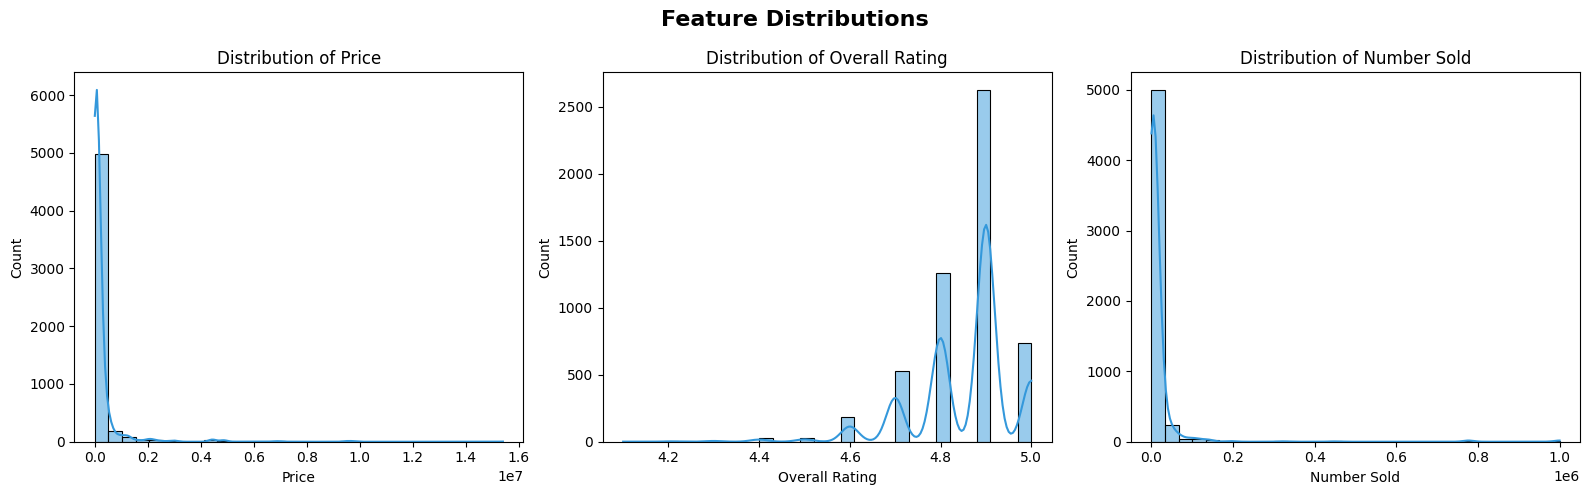

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Feature Distributions", fontsize=16, fontweight="bold")

for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="#3498db")
    axes[i].set_title(f'Distribution of {col}')
    
plt.tight_layout()
plt.show()

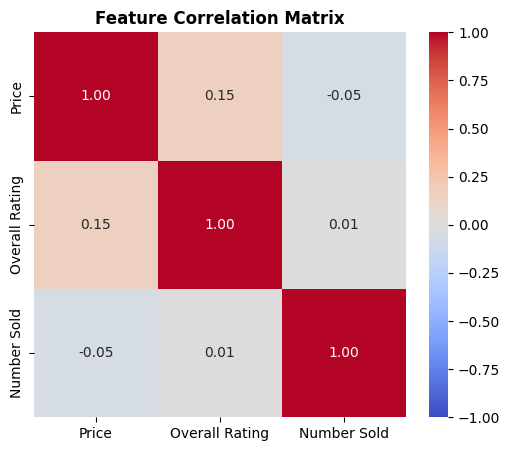

In [9]:
plt.figure(figsize=(6, 5))
correlation_matrix = df[FEATURES].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix", fontweight="bold")
plt.show()

# Data Pre Processing

In [10]:
df["log_price"]      = np.log1p(df["Price"])
df["log_sold_count"] = np.log1p(df["Number Sold"])

In [11]:
SCALED_FEATURES = ["log_price", "Overall Rating", "log_sold_count"]
X_raw = df[SCALED_FEATURES]

In [12]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Training

In [13]:
K_RANGE    = range(2, 11)
inertias   = []
silhouettes = []

In [14]:
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    print(f"  K={k}  Inertia={km.inertia_:,.1f}  Silhouette={silhouettes[-1]:.4f}")


  K=2  Inertia=11,361.8  Silhouette=0.2788
  K=3  Inertia=8,450.2  Silhouette=0.2994
  K=4  Inertia=7,216.6  Silhouette=0.2557
  K=5  Inertia=6,310.9  Silhouette=0.2605
  K=6  Inertia=5,599.1  Silhouette=0.2699
  K=7  Inertia=5,102.3  Silhouette=0.2762
  K=8  Inertia=4,663.6  Silhouette=0.2604
  K=9  Inertia=4,312.5  Silhouette=0.2727
  K=10  Inertia=4,038.6  Silhouette=0.2727


In [15]:
best_k = K_RANGE.start + silhouettes.index(max(silhouettes))


In [16]:
kmeans       = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels    = kmeans.fit_predict(X_scaled)
df["km_cluster"] = km_labels

In [17]:
centroids_scaled = kmeans.cluster_centers_
centroids_raw    = scaler.inverse_transform(centroids_scaled)
centroid_df      = pd.DataFrame(centroids_raw, columns=SCALED_FEATURES)
centroid_df["cluster"] = range(best_k)

In [18]:
price_rank = centroid_df["log_price"].rank()
rating_rank = centroid_df["Overall Rating"].rank()
sold_rank   = centroid_df["log_sold_count"].rank()
score_premium     = price_rank + rating_rank
score_mass_market = sold_rank + (best_k + 1 - price_rank)
score_failed      = (best_k + 1 - rating_rank) + (best_k + 1 - sold_rank)


In [19]:
used = set()
label_map = {}
for name, scores in [("Premium", score_premium),
                     ("Massal", score_mass_market),
                     ("Gagal", score_failed)]:
    best = scores.idxmax()
    while best in used:
        scores[best] = -999
        best = scores.idxmax()
    label_map[best] = name
    used.add(best)

In [20]:
for idx in range(best_k):
    if idx not in label_map:
        label_map[idx] = "Niche"

df["km_segment"] = df["km_cluster"].map(label_map)

In [21]:
print("\n  Cluster centroids (original scale):")
centroid_display = df.groupby("km_segment")[FEATURES].mean().round(2)
print(centroid_display.to_string())



  Cluster centroids (original scale):
                Price  Overall Rating  Number Sold
km_segment                                        
Gagal        99968.97            4.71      2873.98
Massal       32498.55            4.88     35984.05
Premium     534473.17            4.92      2931.16


# Evaluate

C:\Users\lenovo\AppData\Local\Temp\ipykernel_34932\2079502982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='km_segment', order=df['km_segment'].value_counts().index, palette='viridis')


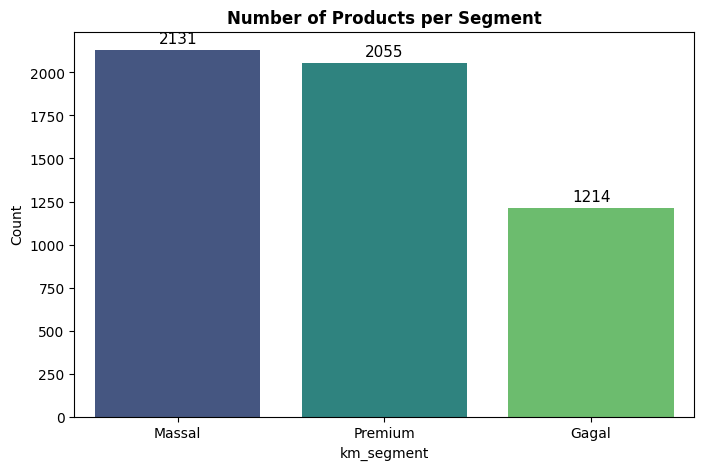

In [22]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='km_segment', order=df['km_segment'].value_counts().index, palette='viridis')
plt.title("Number of Products per Segment", fontweight="bold")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_34932\672770869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='km_segment', y=col, palette='Set2', ax=axes[i])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_34932\672770869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='km_segment', y=col, palette='Set2', ax=axes[i])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_34932\672770869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='km_segment', y=col, palette='Set2', ax=axes[i])


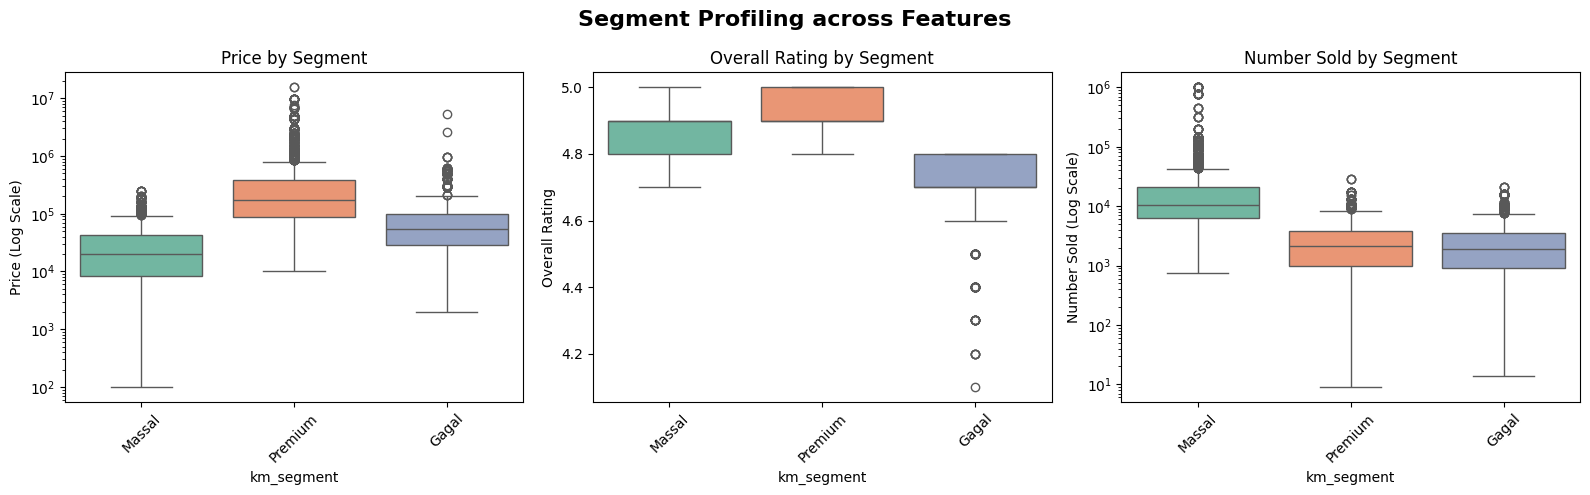

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Segment Profiling across Features", fontsize=16, fontweight="bold")

for i, col in enumerate(FEATURES):
    sns.boxplot(data=df, x='km_segment', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Segment')
    axes[i].tick_params(axis='x', rotation=45)
    
    if col in ["Price", "Number Sold"]:
        axes[i].set_yscale('log')
        axes[i].set_ylabel(f'{col} (Log Scale)')

plt.tight_layout()
plt.show()

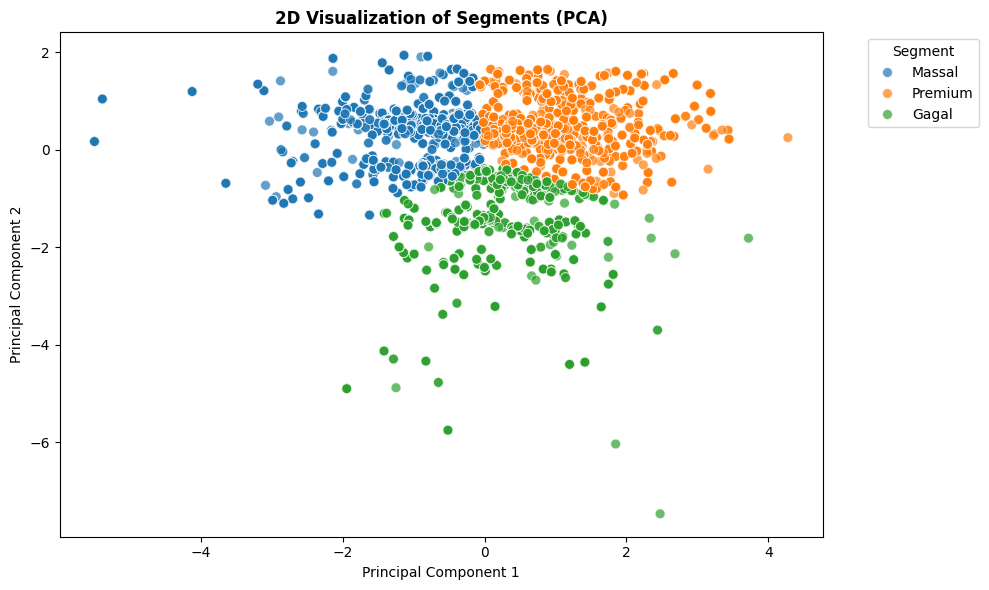

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='km_segment', palette='tab10', alpha=0.7, s=50)
plt.title("2D Visualization of Segments (PCA)", fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save Model

In [25]:
import joblib


In [26]:
joblib.dump(kmeans, f"./kmeans_model.pkl")


['./kmeans_model.pkl']

In [27]:
joblib.dump(scaler, "./scaler.pkl")

['./scaler.pkl']